# Mamaearth Returns & Growth Intelligence - Colab Walkthrough

This notebook runs the capstone in the required order: **SQLite reports -> pandas cleaning and EDA -> charts -> AI/GenAI SCR narrative**. The required SQL and Python scripts remain the source of truth in this repository.

[Repository README](https://github.com/amitkumar0000xyz-a11y/capstone_project-amit-kumar)

If you open this notebook directly from GitHub in Colab, the first code cell clones the repository. The Gemini API key is optional: without it, the notebook runs the deterministic offline narrator. To try Gemini, add a Colab Secret named `GEMINI_API_KEY`; do not paste a key into a notebook cell or commit it to GitHub.

## 1. Locate the repository and install its Python requirements

The notebook works from a cloned repository or from Colab's temporary `/content` directory. It installs the dependencies declared by `requirements.txt` so pandas, Matplotlib, and the Gemini client are available.

In [32]:
from pathlib import Path
import os
import subprocess
import sys

REPO_URL = "https://github.com/amitkumar0000xyz-a11y/capstone_project-amit-kumar.git"

def find_repo(start):
    for candidate in (start, *start.parents):
        if (candidate / "analysis" / "clean_and_eda.py").exists():
            return candidate
    return None

ROOT = find_repo(Path.cwd().resolve())
if ROOT is None:
    ROOT = Path("/content/capstone_project-amit-kumar")
    if not (ROOT / ".git").exists():
        subprocess.run(["git", "clone", REPO_URL, str(ROOT)], check=True)

print("Project directory:", ROOT)
subprocess.run(
    [sys.executable, "-m", "pip", "install", "-q", "-r", str(ROOT / "requirements.txt")],
    check=True,
)


Project directory: /content/capstone_project-amit-kumar


CompletedProcess(args=['/usr/bin/python3', '-m', 'pip', 'install', '-q', '-r', '/content/capstone_project-amit-kumar/requirements.txt'], returncode=0)

## 2. Run the SQLite layer first

This executes `schema.sql`, `seed_data.sql`, and `reports.sql` in order using Python's built-in SQLite engine. Each report query's result is displayed below it. The raw SQL layer retains all 180 order rows, including duplicates and blank ratings/discounts as SQL `NULL`.

In [33]:
import sqlite3
import pandas as pd
from IPython.display import display

DB_PATH = ROOT / "mamaearth.db"
connection = sqlite3.connect(DB_PATH)

def run_sql_file(connection, sql_path):
    source = sql_path.read_text(encoding="utf-8")
    source_without_comments = "\n".join(
        line for line in source.splitlines()
        if not line.lstrip().startswith("--")
    )
    statements = [part.strip() for part in source_without_comments.split(";") if part.strip()]
    print(f"\n--- {sql_path.relative_to(ROOT)} ---")
    for statement_number, statement in enumerate(statements, start=1):
        cursor = connection.execute(statement)
        if cursor.description:
            rows = cursor.fetchall()
            if rows:
                print(f"Result {statement_number}")
                display(pd.DataFrame(rows, columns=[column[0] for column in cursor.description]))

for sql_name in ("schema.sql", "seed_data.sql", "reports.sql"):
    run_sql_file(connection, ROOT / "sql" / sql_name)

print("\nSQL row counts:", connection.execute(
    "SELECT (SELECT COUNT(*) FROM customers), (SELECT COUNT(*) FROM products), (SELECT COUNT(*) FROM orders)"
).fetchone())
connection.close()



--- sql/schema.sql ---

--- sql/seed_data.sql ---

--- sql/reports.sql ---
Result 1


,total_orders,total_revenue,avg_order_value
0,180,99860.20,554.78


Result 2


,all_orders,rated_orders,unrated_orders
0,180,165,15


Result 3


...

Result 10


,acquisition_source
0,Ad
1,Organic
2,Referral
3,Social


Result 13


,loyalty_tier,customer_count
0,Gold,28
1,Silver,17



SQL row counts: (45, 16, 180)


## 3. Run the pandas cleaning and analysis layer

Part 2 independently reads the original CSVs rather than querying SQLite. It prints each acceptance check, writes `analysis/eda_results.json`, and computes `narrator/findings.json` for the narrator.

In [34]:
import sys
sys.path.insert(0, str(ROOT / "analysis"))
from clean_and_eda import run_pipeline

results = run_pipeline()


PART 2 - PYTHON / PANDAS DATA WRANGLING & EDA

TASK 1 - LOAD AND INSPECT
customers.shape = (45, 6)
products.shape  = (16, 4)
orders.shape before cleaning = (180, 9)
orders dtypes:
 order_id           object
customer_id        object
product_id         object
order_date         object
quantity            int64
discount_pct      float64
payment_method     object
rating            float64
returned            int64
raw payment_method unique values: ['CARD', 'COD', 'Card', 'UPI', 'card', 'cod', 'upi']
raw missing values:
 order_id           0
customer_id        0
product_id         0
order_date         0
quantity           0
discount_pct      12
payment_method     0
rating            15
returned           0

TASK 2 - STANDARDIZE PAYMENT METHOD
distinct raw values before standardization: 7
payment_method counts after standardization:
 payment_method
CARD    70
COD     55
UPI     55

TASK 3 - REMOVE DUPLICATE ORDERS BY NATURAL KEY
duplicate rows flagged and removed = 5
dropped order_id values

## 4. Regenerate and view both Matplotlib charts

The revenue chart uses the outlier-corrected monthly series, so March is shown as the genuine peak.

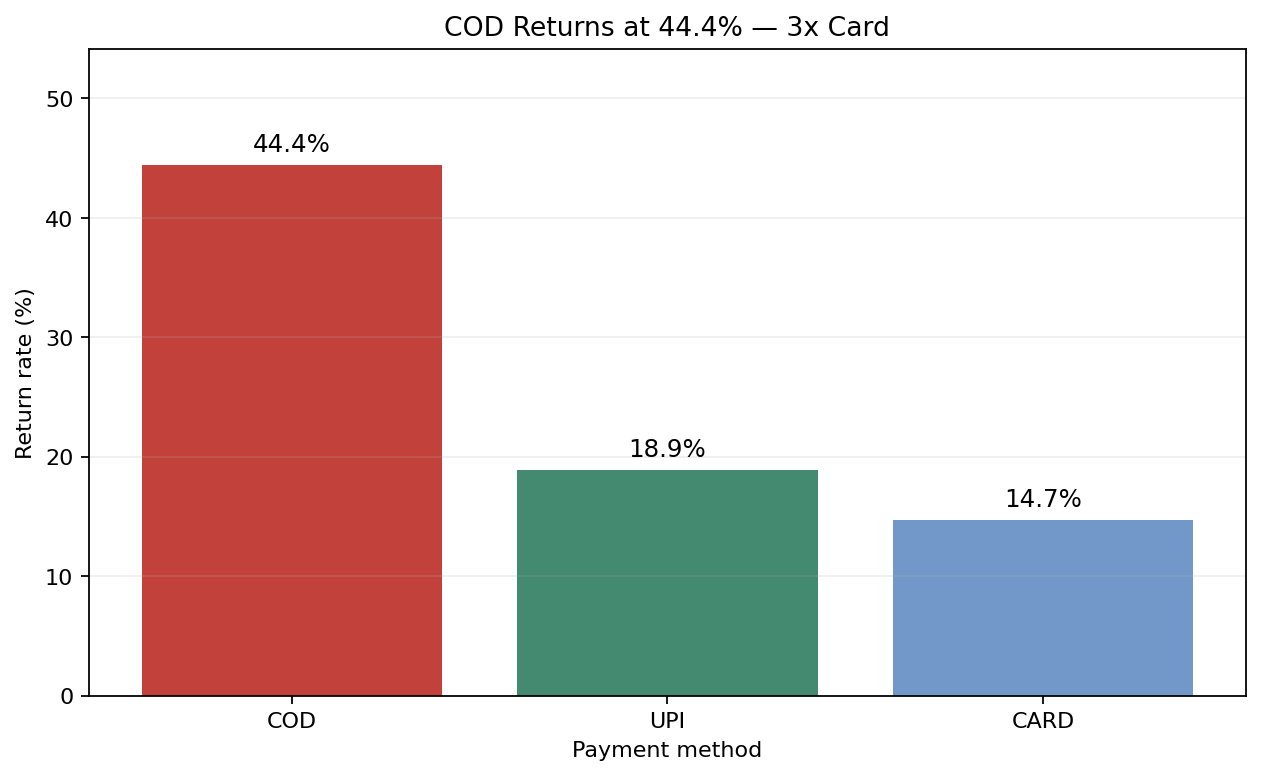

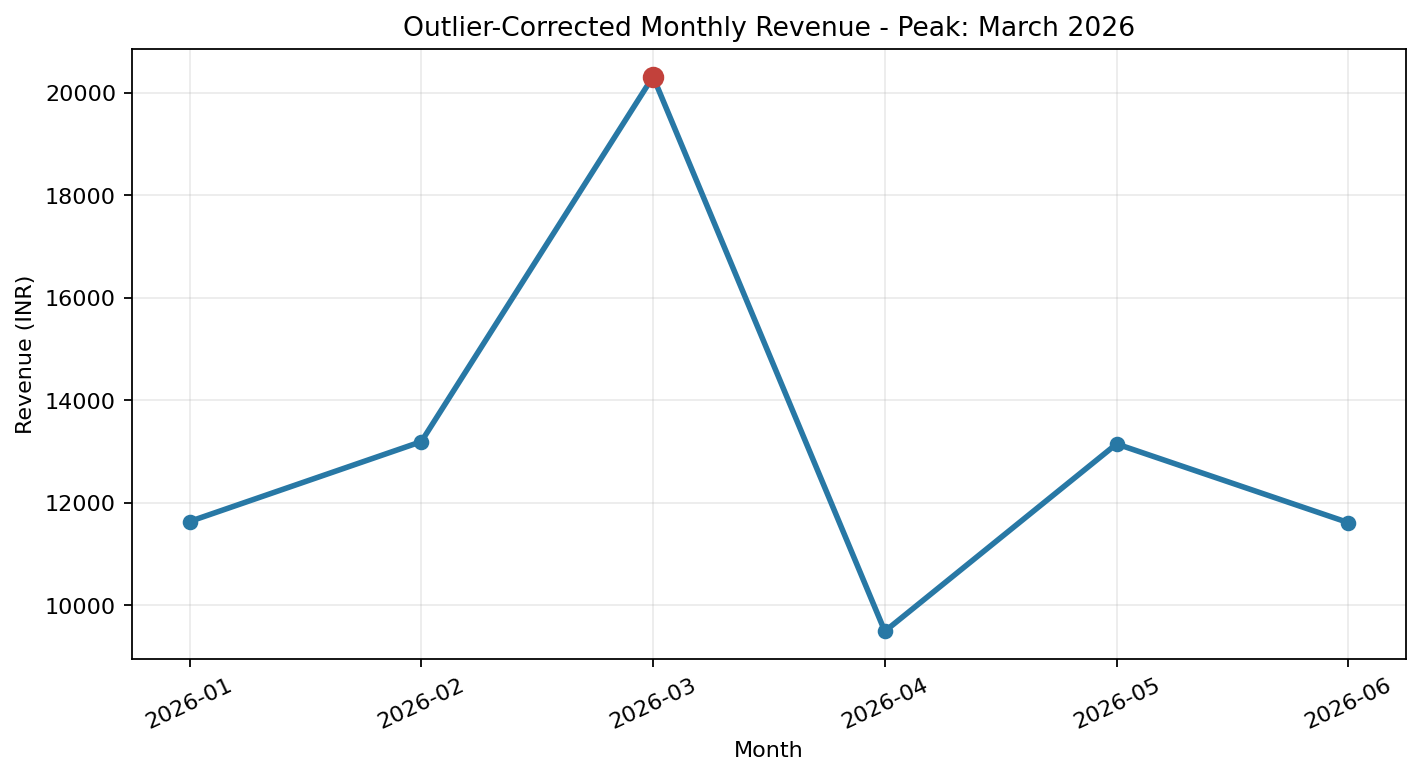

In [35]:
from IPython.display import Image, display

subprocess.run(
    [sys.executable, str(ROOT / "analysis" / "visualize.py")],
    cwd=ROOT,
    check=True,
)
display(Image(filename=str(ROOT / "visualizations" / "return_rate_by_payment.png")))
display(Image(filename=str(ROOT / "visualizations" / "monthly_revenue_trend.png")))


## 5. Generate the AI/GenAI SCR narrative

With a Colab Secret named `GEMINI_API_KEY`, the script calls Gemini and checks the response. If the secret is missing or the API call fails, it automatically uses the keyless offline template. In both cases the numeric checker reads the saved `narrator/sample_output.txt` artifact.

In [36]:
try:
    from google.colab import userdata
    secret = userdata.get("GEMINI_API_KEY")
    if secret:
        os.environ["GEMINI_API_KEY"] = secret
except Exception:
    print("No GEMINI_API_KEY Colab Secret found; the offline narrator will run.")

sys.path.insert(0, str(ROOT / "narrator"))
from generate_narrative import run

narrative_result = run()


Gemini unavailable; using deterministic offline fallback. (503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.', 'status': 'UNAVAILABLE'}})
PASS - cleaned revenue: 97358.30
PASS - COD return rate: 44.4
PASS - COD + Tier-2 segment return rate: 54.5
PASS - duplicate reconciliation delta: 2501.90
PASS - true peak month and revenue: March / 20318.90

Narrative source: offline fallback
Narrative saved to narrator/sample_output.txt (tokens: 0)

Situation
The cleaned order set records INR 97,358.30 in revenue. After quantity outliers are excluded, March (2026-03) is the true peak month at INR 20,318.90.

Complication
The raw SQL total is INR 99,860.20; removing duplicate orders reconciles the total by INR 2,501.90. COD returns are 44.4%, compared with 14.7% for CARD and 18.9% for UPI. The highest-risk segment is COD in Tier-2 cities at 54.5%. The apparent 2026-01 revenue peak of 